In [1]:
import os
import subprocess
import json
from tqdm import tqdm
import time

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy.stats import gaussian_kde
import seaborn as sns
from scipy.stats import mannwhitneyu
from collections import OrderedDict
import matplotlib as mpl

from torch.optim.lr_scheduler import LambdaLR
import math

from utilities import *
from model import *
from sentence_generation_random_link_split import *

In [2]:
print(os.environ.get('CONDA_DEFAULT_ENV'))
nvidia_smi_output = subprocess.check_output(['nvidia-smi']).decode('utf-8')
print(nvidia_smi_output)
torch.cuda.is_available()

netmedgpt
Mon Oct  6 21:56:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.05              Driver Version: 560.35.05      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 PCIe               Off |   00000000:17:00.0 Off |                    0 |
| N/A   35C    P0             82W /  350W |    8120MiB /  81559MiB |      3%      Default |
|                                         |                        |             Disabled |
+-------------------------------------

True

In [4]:
device = torch.device('cuda:0')

with open("/home/bbc8731/NetMedGPT/data/parameters.json", 'r') as file:
    all_param = json.load(file)

data_dir = all_param['files']['data_dir']
best_hyperparam = all_param['best_hyperparam']

os.makedirs(os.path.join(all_param['files']['data_dir'], 'result'), exist_ok = True) 
result_dir = os.path.join(all_param['files']['data_dir'], 'result')

os.makedirs(os.path.join(all_param['files']['data_dir'], "log"), exist_ok=True) 
log_dir = os.path.join(all_param['files']['data_dir'], 'log')

os.makedirs(os.path.join(all_param['files']['data_dir'], "saved_models"), exist_ok=True) 
model_dir = os.path.join(all_param['files']['data_dir'], 'saved_models')


os.makedirs(os.path.join(all_param['files']['data_dir'], "plot"), exist_ok=True) 
clinical_trials_results = os.path.join(all_param['files']['data_dir'], 'plot')


In [6]:
nodes = pd.read_csv(os.path.join(data_dir, 'nodes.csv'), sep= ',')
edge = pd.read_csv(os.path.join(data_dir, "edges_ctg_reduced.csv")) 
feat = torch.load(os.path.join(data_dir, "embeddings_with_feat.pt"))
ctg = pd.read_csv(os.path.join(data_dir, "edges_clinical_trials.csv")) 

In [6]:
all_ids = {
    'drug': torch.tensor(
        nodes.loc[nodes['node_type'] == 'drug', 'node_index'].unique(), dtype=torch.int64
    ),
    'gene': torch.tensor(
        nodes.loc[nodes['node_type'] == 'gene/protein', 'node_index'].unique(), dtype=torch.int64
    ),
    'phenotype': torch.tensor(
        nodes.loc[nodes['node_type'] == 'effect/phenotype', 'node_index'].unique(), dtype=torch.int64
    )
}

# Get mapping from node_types to z_index values
node_type_to_z = edge.groupby('node_types')['z_index'].unique().to_dict()

all_ids_node2 = {}

for z in node_type_to_z.get('disease|drug', []):
    all_ids_node2[z] = all_ids['drug']

for z in node_type_to_z.get('drug|gene/protein', []):
    all_ids_node2[z] = all_ids['gene']

for z in node_type_to_z.get('drug|effect/phenotype', []):
    all_ids_node2[z] = all_ids['phenotype']

In [7]:
# other hyperparameters
mask_token = edge['z_index'].max() +1
vocab_size = mask_token + 1

relation_type = list(edge['relation'].unique())
node_types = list(nodes['node_type'].unique())
node_types_without_feat = ['biological_process',
                           'molecular_function',
                           'cellular_component',
                           'exposure',
                           'pathway',
                           'anatomy']

mask = ['mask']
entity = node_types + relation_type + mask

without_feat = {
    'node': node_types_without_feat,
    'relation': relation_type,
    'mask': mask
}

## find relation_mask_index
relation_index = edge.loc[edge['relation'].isin(relation_type), ['relation', 'z_index']].drop_duplicates()
mask_row = pd.DataFrame([['mask', mask_token]], columns=['relation', 'z_index'])
relation_mask_index = pd.concat([relation_index, mask_row], ignore_index=True)
seq_len = (all_param['node2vec']['walk_length']*2)-1   # walk_length_with_relation

In [11]:
tag = f"{model_dir}/netmedgpt_clinicalTrials"

if len(tag) > 0:
    checkpoint_path = f"{tag}.pt"
    checkpoint_path = os.path.join('model_dir', checkpoint_path)
    checkpoint = torch.load(checkpoint_path, map_location=device)

    param = checkpoint['parameters']
    model = TransformerModel(
        vocab_size,
        best_hyperparam['hidden_channels'],
        best_hyperparam['nhead'],
        best_hyperparam['N_encoder_layers'],
        (all_param['node2vec']['walk_length']*2)-1, #walk_length_with_relation
        device=device,
        feat = feat,
        nodes = nodes,
        entity = entity,
        relation_mask_index = relation_mask_index,
        pos_emb='fixed',
    ).to(device)
    
    # Original checkpoint
    state_dict = checkpoint['model_state_dict']
    model_state = model.state_dict()


    ###### debugging
    model_params = list(model.state_dict().keys())
    checkpoint_params = list(checkpoint['model_state_dict'].keys())
    
    # What parameters exist in checkpoint but not in model
    print("🔎 Params in checkpoint but not in model:", set(checkpoint_params) - set(model_params))
    
    # What parameters exist in model but not in checkpoint
    print("🔎 Params in model but not in checkpoint:", set(model_params) - set(checkpoint_params))
    
    
    # Filter out incompatible keys
    filtered_state_dict = OrderedDict()
    for k, v in state_dict.items():                
        if k in model_state and v.shape == model_state[k].shape:
            filtered_state_dict[k] = v
        # else:
        #     print(f"Skipping {k}: checkpoint shape {v.shape}, model shape {model_state.get(k, 'Not found').shape}")
    
    # Load filtered state dict
    model.load_state_dict(filtered_state_dict, strict=False)
    start_epoch = checkpoint['epoch'] + 1
    loss = checkpoint['loss']

/home/bbc8731/miniconda3/envs/biomedformer/lib/python3.10/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


🔎 Params in checkpoint but not in model: set()
🔎 Params in model but not in checkpoint: set()
86


In [12]:
test_data_edge_label_index = torch.load(os.path.join(data_dir, "test_data_edge_label_index_with_relation_trials_random_splitted_transductive_wl5_wpn30.pt"))
test_data_edge_label = torch.load(os.path.join(data_dir, "test_data_edge_label_trials_random_splitted_transductive_wl5_wpn30.pt"))
edge_type_flag_test = torch.ones(len(test_data_edge_label), dtype=torch.int64)


In [13]:
pred_test = sim_with_logit_efficient_memory(test_data_edge_label_index, model, batch_size=best_hyperparam['batch_size'], method='prob', device=device, mask_token=mask_token, seq_len=seq_len)
pred_test = torch.tensor(pred_test, dtype=torch.float32)

tensor([11.1806, 18.4437, 20.9539,  ...,  7.4972,  8.7582,  7.9845])

In [14]:
test_data = pd.DataFrame(test_data_edge_label_index.T.numpy())
test_data.columns = ['disease', 'relation', 'drug']
test_data['xy'] = test_data['disease'].astype(str) + '|' + test_data['drug'].astype(str)
test_data['label'] = test_data_edge_label
test_data['pred_test'] = pred_test
test_data.loc[:ctg.shape[0]-1, 'label'] = ctg['result'].values  

Match: True


,disease,relation,drug,xy,label,pred_test
0,31116,129389,16086,31116|16086,1,11.180618
1,28849,129389,17605,28849|17605,2,18.443726
2,36050,129389,17605,36050|17605,1,20.953928
3,31116,129389,17605,31116|17605,1,15.807611
4,30827,129389,17605,30827|17605,1,16.442442
...,...,...,...,...,...,...
14649,99953,129389,15469,99953|15469,0,5.095810
14650,99993,129389,14014,99993|14014,0,13.413891
14651,100023,129389,14546,100023|14546,0,7.497215
14652,100023,129389,16315,100023|16315,0,8.758232


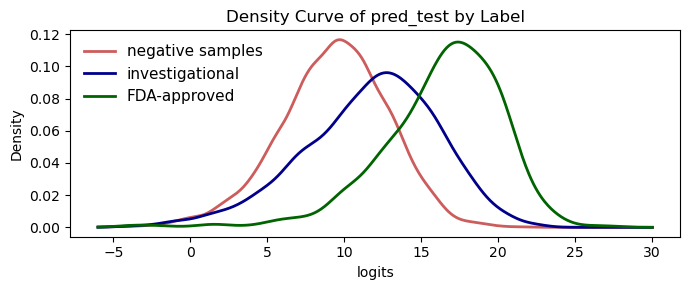

In [15]:
plt.figure(figsize=(7, 3))
# colors = {0: 'lightcoral', 1: 'lightblue', 2: 'lightgreen'}
colors = {0: 'indianred', 1: 'darkblue', 2: 'darkgreen'}

for label in [0, 1, 2]:
    subset = test_data[test_data['label'] == label]['pred_test']
    if len(subset) > 1:  # gaussian_kde needs >1 point
        kde = gaussian_kde(subset)
        x_vals = np.linspace(-6, 30, 500)
        y_vals = kde(x_vals)
        legend_labels = {0: "negative samples", 1: "investigational", 2: "FDA-approved"}
        plt.plot(x_vals, y_vals, label=legend_labels[label], color=colors[label], linewidth=2)

        # plt.fill_between(x_vals, y_vals, alpha=0.4, color=colors[label])

plt.title("Density Curve of pred_test by Label")
plt.xlabel("logits")
plt.ylabel("Density")
plt.legend(loc='upper left', frameon=False, fontsize=11)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(clinical_trials_results, "clinicaltrials_curve.pdf"), format="pdf", bbox_inches="tight")
plt.show()

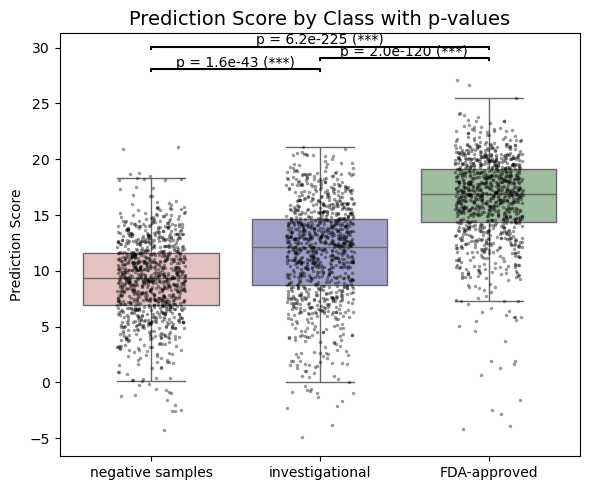

In [16]:
def lighten_color(color, amount=0.6):
    """
    Lightens the given color by multiplying (1 - amount) to the RGB channel and adding `amount`
    of white (1.0). `amount=0.6` gives a very pale color.
    """
    c = np.array(to_rgb(color))
    white = np.ones(3)
    return tuple(c * (1 - amount) + white * amount)
###################################
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],  # or try Arial if installed
})


color_dict = {
    "negative samples": lighten_color('indianred', 0.6),
    "investigational": lighten_color('darkblue', 0.6),
    "FDA-approved": lighten_color('darkgreen', 0.6)
}

# Copy test data
df = test_data.copy()

# Balance all three classes to the same size
n = min(df['label'].value_counts()[[0, 1, 2]])
df_balanced = pd.concat([
    df[df['label'] == 0].sample(n=n, random_state=42),
    df[df['label'] == 1].sample(n=n, random_state=42),
    df[df['label'] == 2].sample(n=n, random_state=42)
]).copy()

df_balanced['label_str'] = df_balanced['label'].map({0: "negative samples", 1: "investigational", 2: "FDA-approved"})
label_order = ["negative samples", "investigational", "FDA-approved"]

plt.figure(figsize=(6, 5))
ax = sns.boxplot(
    x='label_str', y='pred_test',
    hue='label_str',
    data=df_balanced,
    palette=color_dict,
    order=label_order,
    dodge=False,
    fliersize=0,
    legend=False
)
sns.stripplot(
    x='label_str', y='pred_test',
    data=df_balanced,
    order=label_order,
    color='black', size=2.5, jitter=0.2, alpha=0.4, ax=ax
)


# Compute and annotate p-values
positions = {label: i for i, label in enumerate(label_order)}
y_base = df_balanced['pred_test'].max() + 1  # Reduce base level
height = 1

pairs = [("negative samples", "investigational"), ("investigational", "FDA-approved"), ("negative samples", "FDA-approved")]

for i, (label_a, label_b) in enumerate(pairs):
    group_a = df_balanced[df_balanced['label_str'] == label_a]['pred_test']
    group_b = df_balanced[df_balanced['label_str'] == label_b]['pred_test']
    stat, pval = mannwhitneyu(group_a, group_b, alternative='two-sided')

    stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'

    x1, x2 = positions[label_a], positions[label_b]
    y = y_base + i * height

    ax.plot([x1, x1, x2, x2], [y - 0.2, y, y, y - 0.2], lw=1.5, color='k')
    ax.text((x1 + x2) / 2, y + 0.2, f"p = {pval:.1e} ({stars})", ha='center', fontsize=10)

# Styling
ax.set_xlabel("")
ax.set_ylabel("Prediction Score")
ax.set_title("Prediction Score by Class with p-values", fontsize=14)
ax.set_ylim(top=y + 1.2)  # Add space above annotations
# plt.grid(True, linestyle='--', alpha=0.5)

# Increase top margin to prevent clipping
plt.subplots_adjust(top=0.9)
plt.tight_layout()
plt.savefig(os.path.join(clinical_trials_results, "boxplot_clinicaltrials.pdf"), format="pdf", bbox_inches="tight")

plt.show()
